In [ ]:
import numpy as np
import numpy.random as rd

rng = rd.default_rng()

# ----- 1a -----
def tossCoin(p):
    return rng.random()<p

# ----- 1b -----
tosses = [tossCoin(0.25) for i in range(10)]
nSuccess = sum(tosses)
print(nSuccess)

# ----- 1c -----
binomExp = rng.binomial(10, 0.25, 100)

meanBinom = sum(binomExp)/len(binomExp)
meanBinom = np.mean(binomExp)
print(binomExp)
print(meanBinom)

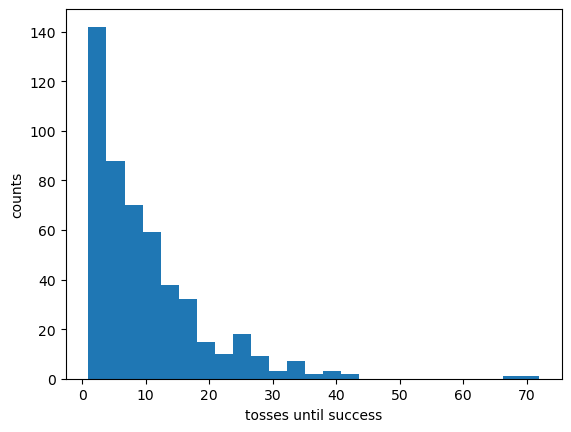

In [2]:
# ----- 2a ------

def tossUntilSuccess(p):
    success = False
    m = 0
    while not success:
        toss = tossCoin(p)
        m += 1
        success = toss
    return m

tosses = []
nRuns = 500
p = 0.1
for i in range(nRuns):
    tosses.append(tossUntilSuccess(p))

import matplotlib.pyplot as plt

plt.hist(tosses, bins=25)
plt.xlabel("tosses until success")
plt.ylabel("counts")
plt.show()

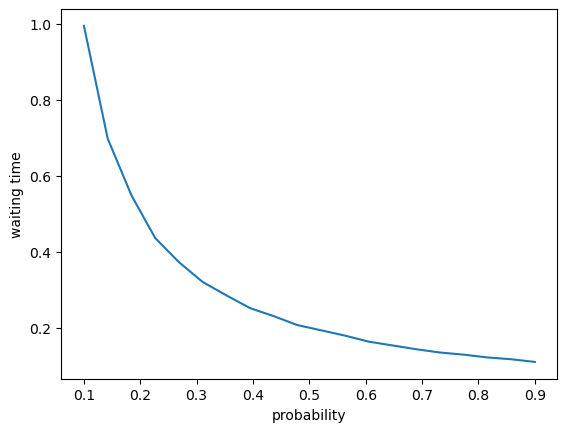

In [5]:
# ----- 2b -----

def tossCoin(p):
    return rng.random()<p

# run one "waiting time" experiment
def waitingTime(p, deltaT):
    counts = 0
    success = False
    while not success:
        success = tossCoin(p)
        counts += 1
    return counts*deltaT

def expectedWaitingTime(prob, dt, trials):
    times = [waitingTime(prob, dt) for i in range(trials)]
    return np.mean(times)

pVals = np.linspace(0.1, 0.9, 20)
WaitingTimes = [expectedWaitingTime(p, 0.1, 5000) for p in pVals]
# print(WaitingTimes)

plt.plot(pVals,WaitingTimes)
plt.xlabel("probability")
plt.ylabel("waiting time")
plt.show()

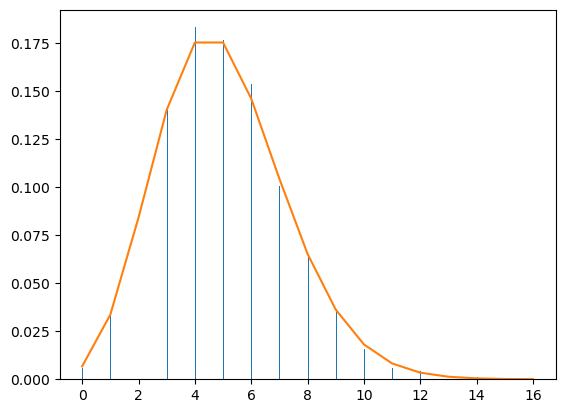

In [6]:
# ----- problem 3 -----

nTrials = 5000

def experiment(mitRate, T):
    t = 0
    nDivisions = 0
    while t<T:
        divisionTime = rng.exponential(1/mitRate)
        t += divisionTime
        if t>T:
            break
        nDivisions += 1
    
    return nDivisions

experiment(0.5, 10);

experimentResults = [experiment(0.5, 10) for i in range(nTrials)]

from scipy.stats import poisson
# poisson pmf
xVals = range(0,17)
yVals = poisson.pmf(xVals, 0.5*10)

plt.hist(experimentResults, bins=450, density=False, weights=[1/nTrials for i in range(nTrials)])
plt.plot(xVals, yVals)
plt.show()